# Práctica 4 - Examen Parcial
## Alberto Besné Cabrera - 317012743
### Minería de Datos 2025
### Profesor: Arturo Soto
#### Mayo 2025

## Librerías

In [1]:
import pandas as pd
from tkinter import Tk
from tkinter.filedialog import askopenfilenames
import glob
import os
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Preprocesamiento de archivos CSV

### Objetivo
Preparar los archivos CSV para su correcta inserción en una base de datos, eliminando cualquier fila que no forme parte de los datos reales, como los encabezados.

### Descripción del proceso
- Recepción de archivos CSV:
Se parte de una colección de archivos CSV que contienen registros de viajes del sistema ECOBICI.
Cada archivo representa un subconjunto de datos, pero todos comparten la misma estructura de columnas.

- Eliminación de encabezados:
Aunque los archivos CSV pueden contener encabezados (nombres de columnas), estos no son necesarios para la inserción en la base de datos, ya que la tabla destino ya tiene definidos sus nombres de columnas.

- Se utiliza un script en Python que:
Lee cada archivo CSV sin interpretar la primera fila como encabezado (header=None).
Elimina la primera fila del archivo (df.iloc[1:]), que corresponde a los títulos de columna.
Guarda el archivo limpio o lo mantiene en memoria para su posterior uso.

- Resultado:
Se obtiene una colección de archivos CSV sin encabezados, listos para ser insertados directamente en la base de datos.
Esto garantiza que no se generen errores por incompatibilidad de nombres de columnas durante la carga.


In [2]:
def remove_first_row(file_path):
    df = pd.read_csv(file_path, header=None)
    df = df.iloc[1:]
    modified_file_path = file_path.replace('.csv', '_modificado.csv')
    df.to_csv(modified_file_path, index=False, header=False)

def main():
    root = Tk()
    root.withdraw()
    file_paths = askopenfilenames(title="Selecciona los archivos CSV", filetypes=[("CSV files", "*.csv")])
    
    for file_path in file_paths:
        remove_first_row(file_path)

    print("¡Archivos modificados exitosamente!")

if __name__ == "__main__":
    main()

¡Archivos modificados exitosamente!


## Inserción de datos en la base de datos SQLite

### Objetivo
Cargar los datos limpios desde múltiples archivos CSV en una tabla existente de una base de datos SQLite.

### Descripción del proceso
- Conexión a la base de datos:
Se establece una conexión a la base de datos SQLite (ecobici_viajes.db) utilizando la biblioteca sqlite3 de Python.
La tabla de destino se llama ECOBICI y ya ha sido creada previamente con su estructura definida.

- Lectura e inserción de archivos CSV:
Se recorre cada archivo CSV en la carpeta especificada.
Cada archivo se lee sin encabezado (header=None) y se le asignan manualmente los nombres de columna correctos para que coincidan con los de la tabla ECOBICI.
Se utiliza el método to_sql() de pandas para insertar los datos en la tabla, con el parámetro if_exists='append' para agregar los registros sin sobrescribir los existentes.

- Validación de estructura:
Es fundamental que el número y orden de columnas en los archivos CSV coincidan exactamente con los de la tabla ECOBICI.
Si no coinciden, se producirán errores de tipo OperationalError.

- Cierre de conexión:
Una vez insertados todos los datos, se cierra la conexión a la base de datos para liberar recursos.

In [3]:
folder_path = 'ECOBICI/2025' 
column_names = ['Genero_Usuario', 'Edad_Usuario', 'Bici', 'Ciclo_Estacion_Retiro', 'Fecha_Retiro', 'Hora_Retiro', 'Ciclo_Estacion_Arribo', 'Fecha_Arribo', 'Hora_Arribo']
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

if not csv_files:
    print("No se encontraron archivos CSV en la carpeta especificada.")
else:
    conn = sqlite3.connect('practica_DM2025.db')

    for file in csv_files:
        df = pd.read_csv(file, header=None, low_memory=False)
        if df.shape[1] != len(column_names):
            print(f"Error: {file} tiene {df.shape[1]} columnas, pero se esperaban {len(column_names)}.")
            continue
        df.columns = column_names
        df.to_sql('ECOBICI', conn, if_exists='append', index=False)

    conn.close()
    print("¡Datos insertados exitosamente en la tabla 'ECOBICI'!")


¡Datos insertados exitosamente en la tabla 'ECOBICI'!


# Análisis Exploratorio

In [4]:
conn = sqlite3.connect('practica_DM2025.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())
conn.close()

[('ECOBICI',)]


In [6]:
conn = sqlite3.connect('practica_DM2025.db')
query = """
SELECT Genero_Usuario, Edad_Usuario, Ciclo_Estacion_Retiro, Ciclo_Estacion_Arribo,
       Fecha_Retiro, Hora_Retiro, Fecha_Arribo, Hora_Arribo
FROM ECOBICI
"""
chunks = pd.read_sql_query(query, conn, chunksize=50000)

genero, edad, retiro, arribo, duracion = [], [], [], [], []
for chunk in chunks:
    genero.extend(chunk['Genero_Usuario'])
    edad.extend(pd.to_numeric(chunk['Edad_Usuario'], errors='coerce'))
    retiro.extend(chunk['Ciclo_Estacion_Retiro'])
    arribo.extend(chunk['Ciclo_Estacion_Arribo'])

    retiro_dt = pd.to_datetime(chunk['Fecha_Retiro'] + ' ' + chunk['Hora_Retiro'],
                               format='%d/%m/%Y %H:%M:%S', errors='coerce')
    arribo_dt = pd.to_datetime(chunk['Fecha_Arribo'] + ' ' + chunk['Hora_Arribo'],
                               format='%d/%m/%Y %H:%M:%S', errors='coerce')
    duracion.extend((arribo_dt - retiro_dt).dt.total_seconds() / 60)

df_genero = pd.Series(genero, name='Genero_Usuario')
df_edad = pd.Series(edad, name='Edad_Usuario').dropna()
df_retiro = pd.Series(retiro, name='Ciclo_Estacion_Retiro')
df_arribo = pd.Series(arribo, name='Ciclo_Estacion_Arribo')
df_duracion = pd.Series(duracion, name='Duracion_Minutos')

print("Resumen estadístico de Edad_Usuario:")
print(df_edad.describe())

print("\nDuración promedio del viaje (minutos):")
print(df_duracion.mean())

print("\nDistribución por Género:")
print(df_genero.value_counts())

print("\nEstaciones más usadas para Retiro:")
print(df_retiro.value_counts().head(10))

print("\nEstaciones más usadas para Arribo:")
print(df_arribo.value_counts().head(10))


Resumen estadístico de Edad_Usuario:
count    1.277247e+08
mean     3.446357e+01
std      1.007399e+01
min      2.000000e+00
25%      2.700000e+01
50%      3.200000e+01
75%      4.000000e+01
max      1.600000e+02
Name: Edad_Usuario, dtype: float64

Duración promedio del viaje (minutos):
23.63662562832654

Distribución por Género:
Genero_Usuario
M                 91700058
F                 34312702
O                  1031772
?                   246519
Genero_Usuario           4
Name: count, dtype: int64

Estaciones más usadas para Retiro:
Ciclo_Estacion_Retiro
27    1237420
1      997321
64     942227
18     906753
41     876141
36     854659
43     746484
28     689640
31     668745
19     666427
Name: count, dtype: int64

Estaciones más usadas para Arribo:
Ciclo_Estacion_Arribo
27         1263783
1          1034959
64         1004305
18          897982
43          884618
271-272     847071
36          839821
14          781756
41          736228
29          706220
Name: count, dtype: 

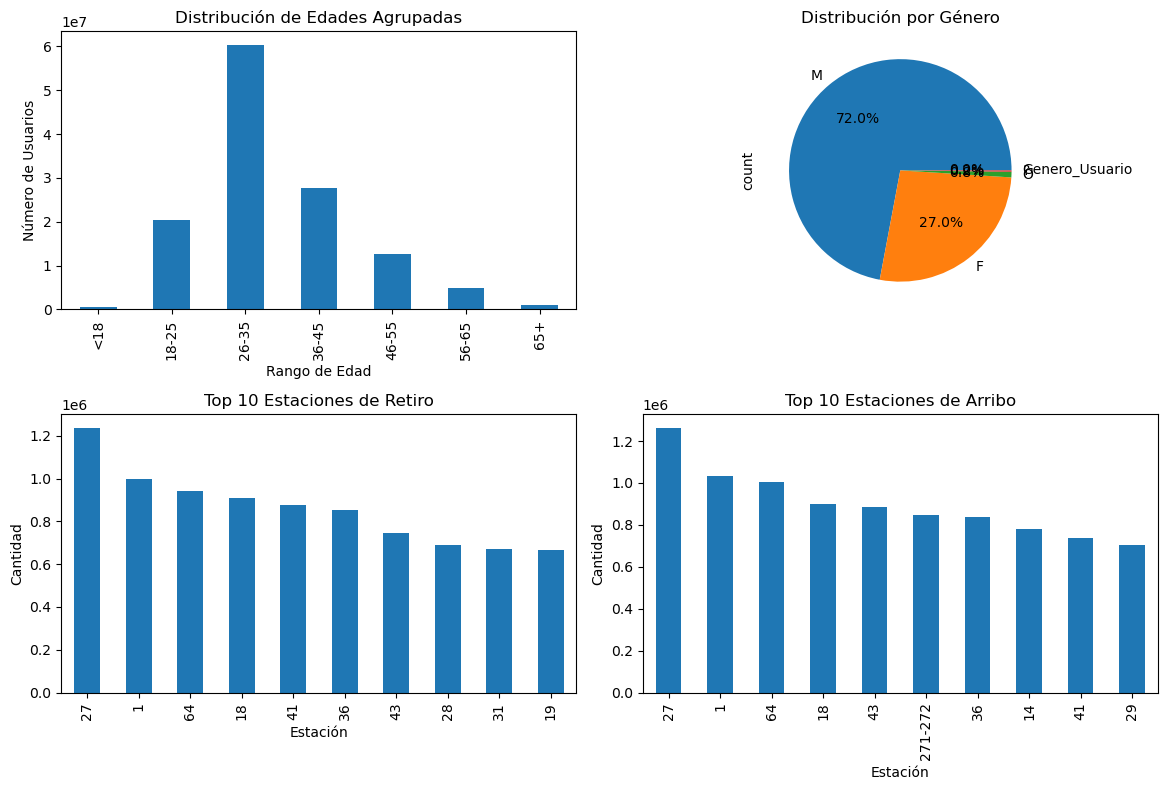

In [7]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_edad_binned = pd.cut(df_edad, bins=bins, labels=labels)

plt.figure(figsize=(12, 8))

# Distribución de Edades Agrupadas
plt.subplot(2, 2, 1)
df_edad_binned.value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de Edades Agrupadas')
plt.xlabel('Rango de Edad')
plt.ylabel('Número de Usuarios')

# Distribución por Género
plt.subplot(2, 2, 2)
df_genero.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución por Género')

# Top 10 Estaciones de Retiro
plt.subplot(2, 2, 3)
df_retiro.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Estaciones de Retiro')
plt.xlabel('Estación')
plt.ylabel('Cantidad')

# Top 10 Estaciones de Arribo
plt.subplot(2, 2, 4)
df_arribo.value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Estaciones de Arribo')
plt.xlabel('Estación')
plt.ylabel('Cantidad')

plt.tight_layout()
plt.savefig('eda_visualizaciones.png')
plt.show()

# Boxplot de duración de viajes por género

<Figure size 1000x600 with 0 Axes>

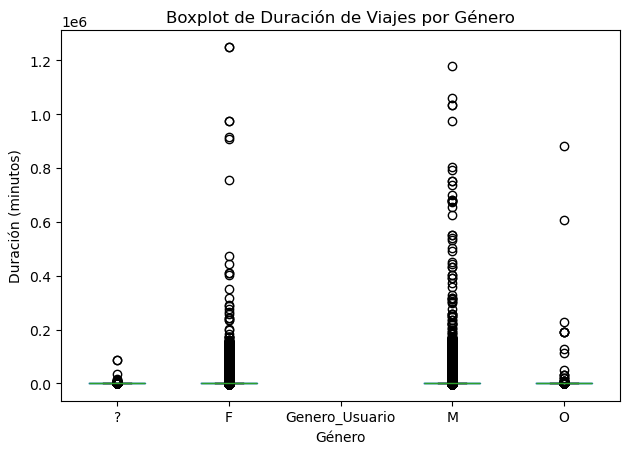

In [8]:
df_duracion_genero = pd.DataFrame({'Duracion': df_duracion, 'Genero': df_genero})

plt.figure(figsize=(10, 6))
df_duracion_genero.boxplot(column='Duracion', by='Genero', grid=False)
plt.title('Boxplot de Duración de Viajes por Género')
plt.suptitle('')
plt.xlabel('Género')
plt.ylabel('Duración (minutos)')
plt.tight_layout()
plt.savefig('boxplot_duracion_genero.png')
plt.show()


# Clustering

## Segmentación clara:

- Cluster 0: Usuarios jóvenes (~30 años), viajes cortos, mayoría hombres.
- Cluster 1: Adultos (~33 años), viajes moderados, mayoría mujeres.
- Cluster 2: Usuarios mayores (~49 años), viajes largos, mayoría hombres.

## Duración y edad están correlacionadas:

- A mayor edad, mayor duración promedio del viaje.

## Distribución de género desigual:

- Algunos clusters están dominados por un solo género, lo que puede reflejar patrones de uso diferenciados.

In [9]:
import pandas as pd
import numpy as np
import sqlite3
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Conexión a la base de datos
conn = sqlite3.connect('practica_DM2025.db')
query = """
SELECT Genero_Usuario, Edad_Usuario, Ciclo_Estacion_Retiro, Ciclo_Estacion_Arribo,
       Fecha_Retiro, Hora_Retiro, Fecha_Arribo, Hora_Arribo
FROM ECOBICI
"""
chunks = pd.read_sql_query(query, conn, chunksize=100000)

# Lista para almacenar muestras
muestras = []

for chunk in chunks:
    chunk['Edad_Usuario'] = pd.to_numeric(chunk['Edad_Usuario'], errors='coerce')
    retiro_dt = pd.to_datetime(chunk['Fecha_Retiro'] + ' ' + chunk['Hora_Retiro'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
    arribo_dt = pd.to_datetime(chunk['Fecha_Arribo'] + ' ' + chunk['Hora_Arribo'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
    chunk['Duracion_Minutos'] = (arribo_dt - retiro_dt).dt.total_seconds() / 60

    # Filtrar y limpiar
    chunk = chunk[['Genero_Usuario', 'Edad_Usuario', 'Duracion_Minutos']].dropna()
    chunk = chunk[chunk['Duracion_Minutos'] > 0]

    # Muestreo aleatorio del 1% del chunk
    muestra = chunk.sample(frac=0.01, random_state=42)
    muestras.append(muestra)

# Unir todas las muestras
df = pd.concat(muestras, ignore_index=True)

# Codificación de género
df['Genero_F'] = (df['Genero_Usuario'] == 'F').astype(int)
df['Genero_M'] = (df['Genero_Usuario'] == 'M').astype(int)
df['Genero_O'] = ((df['Genero_Usuario'] != 'F') & (df['Genero_Usuario'] != 'M')).astype(int)

# Variables para clustering
X = df[['Edad_Usuario', 'Duracion_Minutos', 'Genero_F', 'Genero_M', 'Genero_O']]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Perfilado de clusters
cluster_profile = df.groupby('Cluster').agg({
    'Edad_Usuario': ['mean', 'std'],
    'Duracion_Minutos': ['mean', 'std'],
    'Genero_F': 'sum',
    'Genero_M': 'sum',
    'Genero_O': 'sum'
}).reset_index()

# Renombrar columnas
cluster_profile.columns = [
    'Cluster', 'Edad_Media', 'Edad_Std',
    'Duracion_Media', 'Duracion_Std',
    'Genero_F', 'Genero_M', 'Genero_O'
]

# Mostrar resultados
print(cluster_profile)

C:\Users\BESNEA\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\BESNEA\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


   Cluster  Edad_Media  Edad_Std  Duracion_Media  Duracion_Std  Genero_F  \
0        0   48.189393  7.898295       42.819681   1572.942298       128   
1        1   32.946738  9.047345       20.425217    528.487409    247717   
2        2   29.612362  4.890669       16.655417    195.124978         0   

   Genero_M  Genero_O  
0    198003       831  
1         0         0  
2    456482     11800  


In [ ]:
# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Silhouette Score
score = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score: {score:.4f}")

# Perfilado de clusters
cluster_profile = df.groupby('Cluster').agg({
    'Edad_Usuario': ['mean', 'std'],
    'Duracion_Minutos': ['mean', 'std'],
    'Genero_F': 'sum',
    'Genero_M': 'sum',
    'Genero_O': 'sum'
}).reset_index()
cluster_profile.columns = [
    'Cluster', 'Edad_Media', 'Edad_Std',
    'Duracion_Media', 'Duracion_Std',
    'Genero_F', 'Genero_M', 'Genero_O'
]
print(cluster_profile)

# Visualizaciones
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Cluster', y='Edad_Media', data=cluster_profile)
plt.title('Edad Media por Cluster')

plt.subplot(1, 2, 2)
sns.barplot(x='Cluster', y='Duracion_Media', data=cluster_profile)
plt.title('Duración Media por Cluster')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Edad_Usuario', y='Duracion_Minutos', hue='Cluster', data=df, palette='viridis')
plt.title('Dispersión Edad vs Duración por Cluster')
plt.xlabel('Edad')
plt.ylabel('Duración (minutos)')
plt.legend(title='Cluster')
plt.show()

cluster_profile_melted = cluster_profile.melt(id_vars='Cluster', value_vars=['Genero_F', 'Genero_M', 'Genero_O'], var_name='Genero', value_name='Cantidad')
plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster', y='Cantidad', hue='Genero', data=cluster_profile_melted)
plt.title('Distribución de Género por Cluster')
plt.show()
